In [1]:
#glob is used for finding patterns in path names
import glob
#pandas is used for the creation and manipulation of dataframes
import pandas as pd
import numpy as np
#Used for data exploration and visualising the effectiveness of machine learning model
import seaborn as sns
import matplotlib.pyplot as plt
import lazypredict

In [2]:
#
from padelpy import padeldescriptor
#
from rdkit import Chem
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit import Chem
from rdkit.Chem import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize
#Loading in type of ML model 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
#Compare models
from lazypredict.Supervised import LazyRegressor

In [3]:
#Reading CSV into Python and then filtering empty values
df = pd.read_csv('gamma_raw.csv')
df2 = df[df.standard_value.notna()]
df2 = df[df.canonical_smiles.notna()]
df2 = df.dropna(subset=["standard_value", "value"])
df2 = df2.drop(df[df["type"].str.contains("pIC50")].index)

In [4]:
df2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,306061,[],CHEMBL676871,In vitro inhibition of gamma secretase.,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,1.8
1,NaN,NaN,306062,[],CHEMBL676871,In vitro inhibition of gamma secretase.,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,0.9
2,NaN,NaN,307380,[],CHEMBL676871,In vitro inhibition of gamma secretase.,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,13.2
3,NaN,NaN,311377,[],CHEMBL676871,In vitro inhibition of gamma secretase.,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,1.2
4,NaN,NaN,312782,[],CHEMBL676871,In vitro inhibition of gamma secretase.,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,1884.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3541,"{'action_type': 'MODULATOR', 'description': 'E...",NaN,25886599,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5517241,Modulation of gamma-secretase in human SH-SY5Y...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,4.0
3542,"{'action_type': 'INHIBITOR', 'description': 'N...",NaN,29055316,[],CHEMBL6071528,Inhibition of Gamma-secretase (unknown origin),B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,20.0
3543,"{'action_type': 'INHIBITOR', 'description': 'N...",NaN,29055317,[],CHEMBL6071528,Inhibition of Gamma-secretase (unknown origin),B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,0.4
3544,"{'action_type': 'INHIBITOR', 'description': 'N...",NaN,29055318,[],CHEMBL6071528,Inhibition of Gamma-secretase (unknown origin),B,NaN,NaN,BAO_0000190,...,Homo sapiens,Gamma-secretase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,1.2


In [5]:
len(df2.canonical_smiles.unique())

2409

In [6]:
df2.to_csv("Checkingdata.csv", index = False)

In [7]:
if len(df2.type.unique()) == 1:
    print(True)
else:
    print(False)

True


In [8]:
df2_nr = df2.drop_duplicates(['canonical_smiles'])
selection = ['molecule_chembl_id','canonical_smiles','standard_value']

In [9]:
df3 = df2_nr[selection]
df3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.8
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,0.9
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,13.2
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.2
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1884.0
...,...,...,...
3535,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,25000.0
3536,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,17.0
3538,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,7.0
3540,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,10.0


In [10]:
df3.to_csv("gamma_preprocessed.csv", index=False)

In [11]:
df4 = pd.read_csv('gamma_preprocessed.csv')

In [12]:
#For the purposes of model training the data needs to be classified
#The concentrations are in standard value which is nM
bioactivity_threshold = []
for i in df4.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [13]:
bioactivity_class = pd.Series(bioactivity_threshold, name='bioactivity_class')
df5 = pd.concat([df4, bioactivity_class], axis=1)
df5

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.8,active
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,0.9,active
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,13.2,active
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.2,active
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1884.0,intermediate
...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,25000.0,inactive
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,17.0,active
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,7.0,active
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,10.0,active


In [14]:
df5.to_csv("gamma_classifed.csv", index=False)

In [15]:
df6 = pd.read_csv('gamma_classifed.csv')
df6

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.8,active
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,0.9,active
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,13.2,active
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.2,active
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1884.0,intermediate
...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,25000.0,inactive
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,17.0,active
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,7.0,active
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,10.0,active


In [16]:
#Calculate Lipinski descriptors
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

df_lipinski = lipinski(df6.canonical_smiles)

In [17]:
df_lipinski
df_lipinski.to_csv("gamma_lipinski.csv", index = False)

In [18]:
df_combined = pd.concat([df6,df_lipinski], axis=1)

In [19]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.8,active,477.467,3.80410,2.0,5.0
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,0.9,active,521.520,3.19090,2.0,6.0
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,13.2,active,534.519,2.68390,2.0,6.0
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1.2,active,515.516,4.20610,1.0,5.0
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,1884.0,intermediate,530.575,3.72780,1.0,4.0
...,...,...,...,...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,25000.0,inactive,611.743,2.71720,3.0,6.0
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,17.0,active,671.879,5.56660,4.0,6.0
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,7.0,active,480.494,5.29072,0.0,5.0
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,10.0,active,406.530,6.36616,1.0,4.0


In [20]:
def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis = 1)
        
    return x

In [21]:
df_combined.standard_value.describe()

count      2409.000000
mean       4710.804643
std       15793.102986
min           0.002000
25%          20.000000
50%         140.000000
75%        1000.000000
max      307000.000000
Name: standard_value, dtype: float64

In [22]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis =  1)
        
    return x

In [23]:
df_norm = norm_value(df_combined)
df_norm
df_norm = df_norm[df_norm.NumHAcceptors.notna()]

In [24]:
df_norm

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,477.467,3.80410,2.0,5.0,1.8
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,521.520,3.19090,2.0,6.0,0.9
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,534.519,2.68390,2.0,6.0,13.2
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,515.516,4.20610,1.0,5.0,1.2
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,intermediate,530.575,3.72780,1.0,4.0,1884.0
...,...,...,...,...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,inactive,611.743,2.71720,3.0,6.0,25000.0
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,active,671.879,5.56660,4.0,6.0,17.0
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,active,480.494,5.29072,0.0,5.0,7.0
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,active,406.530,6.36616,1.0,4.0,10.0


In [25]:
df_norm.standard_value_norm.describe()

count      2409.000000
mean       4710.804643
std       15793.102986
min           0.002000
25%          20.000000
50%         140.000000
75%        1000.000000
max      307000.000000
Name: standard_value_norm, dtype: float64

In [26]:
df_final = pIC50(df_norm)
df_final
df_final.to_csv("gamma_bioactivity_pIC50.csv", index=False)

In [27]:
df_final.pIC50.describe()

count    2409.000000
mean        6.815868
std         1.304027
min         3.512862
25%         6.000000
50%         6.853872
75%         7.698970
max        11.698970
Name: pIC50, dtype: float64

In [28]:
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,477.467,3.80410,2.0,5.0,8.744727
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,521.520,3.19090,2.0,6.0,9.045757
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,534.519,2.68390,2.0,6.0,7.879426
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,515.516,4.20610,1.0,5.0,8.920819
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,intermediate,530.575,3.72780,1.0,4.0,5.724919
...,...,...,...,...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,inactive,611.743,2.71720,3.0,6.0,4.602060
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,active,671.879,5.56660,4.0,6.0,7.769551
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,active,480.494,5.29072,0.0,5.0,8.154902
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,active,406.530,6.36616,1.0,4.0,8.000000


In [29]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,477.467,3.80410,2.0,5.0,8.744727
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,521.520,3.19090,2.0,6.0,9.045757
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,534.519,2.68390,2.0,6.0,7.879426
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,515.516,4.20610,1.0,5.0,8.920819
5,CHEMBL423533,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,501.533,4.22860,1.0,4.0,8.443697
...,...,...,...,...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,inactive,611.743,2.71720,3.0,6.0,4.602060
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,active,671.879,5.56660,4.0,6.0,7.769551
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,active,480.494,5.29072,0.0,5.0,8.154902
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,active,406.530,6.36616,1.0,4.0,8.000000


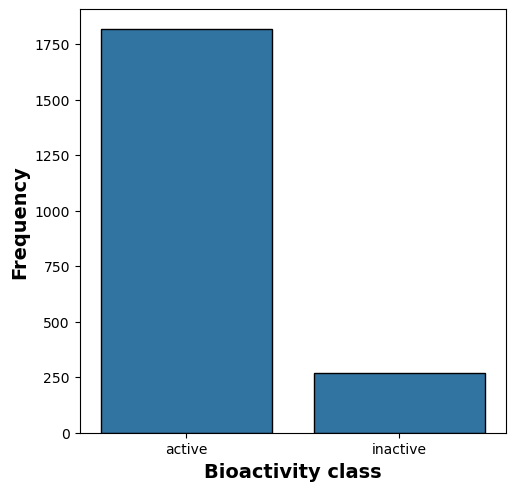

In [30]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

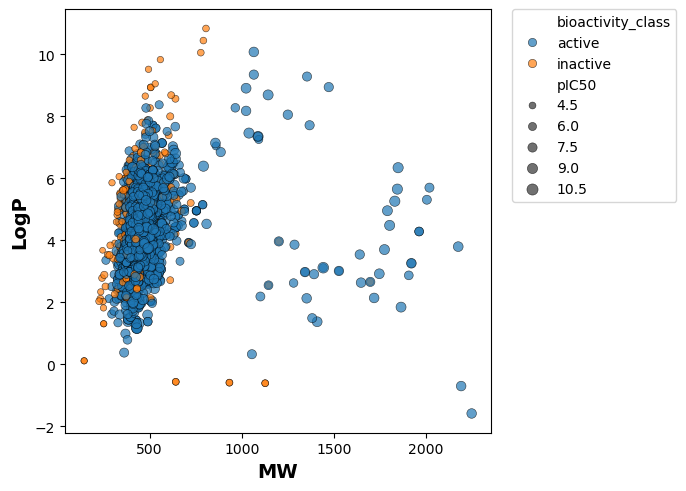

In [31]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

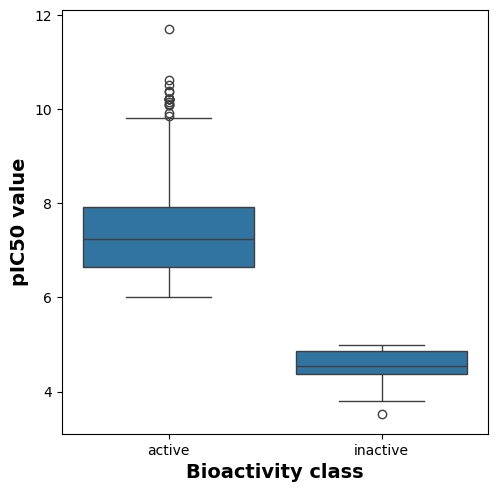

In [32]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

In [33]:

def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [34]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,484872.0,8.073102e-154,0.05,Different distribution (reject H0)


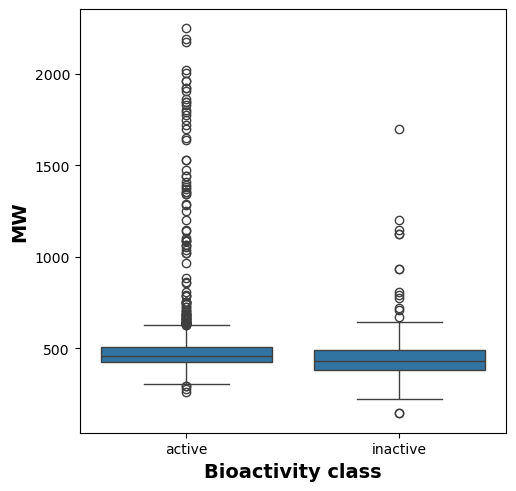

In [35]:

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [36]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,295122.0,9.388469e-09,0.05,Different distribution (reject H0)


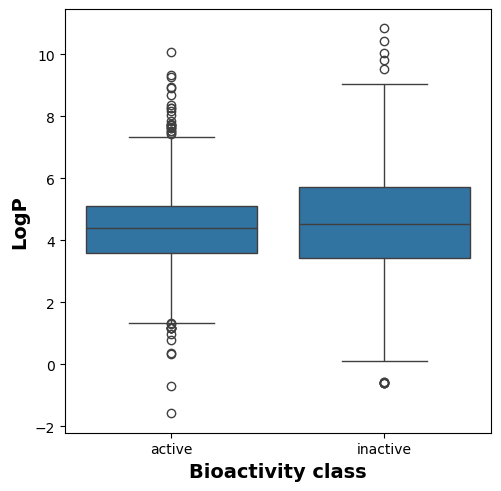

In [37]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

In [38]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,224016.5,0.044727,0.05,Different distribution (reject H0)


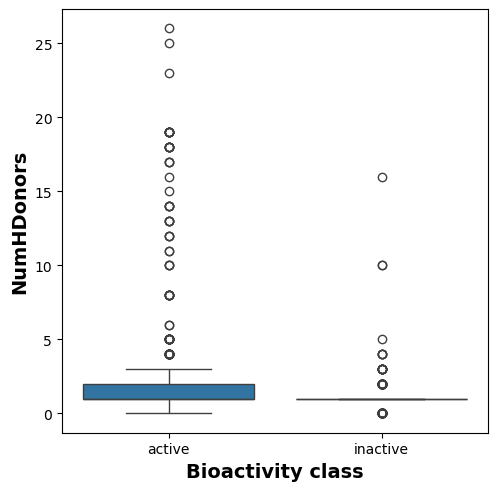

In [39]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

In [40]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,242761.5,0.96916,0.05,Same distribution (fail to reject H0)


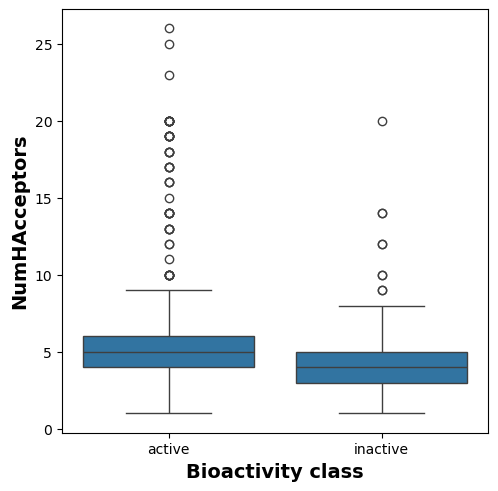

In [41]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [42]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,281447.5,0.000014,0.05,Different distribution (reject H0)


In [43]:
#All of the descriptors showed a significant difference between active and inactive class

In [44]:
df_gamma = pd.read_csv("gamma_bioactivity_pIC50.csv")

In [45]:
df_gamma

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,477.467,3.80410,2.0,5.0,8.744727
1,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,521.520,3.19090,2.0,6.0,9.045757
2,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,534.519,2.68390,2.0,6.0,7.879426
3,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,active,515.516,4.20610,1.0,5.0,8.920819
4,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,intermediate,530.575,3.72780,1.0,4.0,5.724919
...,...,...,...,...,...,...,...,...
2404,CHEMBL601773,CC(C)[C@@]1(NC(=O)[C@@H]2C[C@@H]3c4cccc5[nH]cc...,inactive,611.743,2.71720,3.0,6.0,4.602060
2405,CHEMBL5283881,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)C[C@@H](O)[C...,active,671.879,5.56660,4.0,6.0,7.769551
2406,CHEMBL2151205,COc1nc(/C=C/c2nc3n(n2)CCC[C@H]3c2ccccc2C(F)(F)...,active,480.494,5.29072,0.0,5.0,8.154902
2407,CHEMBL2151100,CCc1cc(Nc2nc(-c3ccc(-n4cnc(C)c4)c(F)c3)cs2)c(C...,active,406.530,6.36616,1.0,4.0,8.000000


In [46]:
selection2 = ['canonical_smiles','molecule_chembl_id']
df_gamma_selection = df_gamma[selection2]
df_gamma_selection.to_csv('molecules.smi', sep='\t', index=False, header=False)

In [47]:
xml_files = glob.glob("*.xml")
xml_files.sort()
xml_files

['AtomPairs2DFingerprintCount.xml',
 'AtomPairs2DFingerprinter.xml',
 'EStateFingerprinter.xml',
 'ExtendedFingerprinter.xml',
 'Fingerprinter.xml',
 'GraphOnlyFingerprinter.xml',
 'KlekotaRothFingerprintCount.xml',
 'KlekotaRothFingerprinter.xml',
 'MACCSFingerprinter.xml',
 'PubchemFingerprinter.xml',
 'SubstructureFingerprintCount.xml',
 'SubstructureFingerprinter.xml']

In [48]:
FP_list = ['AtomPairs2DCount',
 'AtomPairs2D',
 'EState',
 'CDKextended',
 'CDK',
 'CDKgraphonly',
 'KlekotaRothCount',
 'KlekotaRoth',
 'MACCS',
 'PubChem',
 'SubstructureCount',
 'Substructure']

In [49]:
fp = dict(zip(FP_list, xml_files))
fp

{'AtomPairs2DCount': 'AtomPairs2DFingerprintCount.xml',
 'AtomPairs2D': 'AtomPairs2DFingerprinter.xml',
 'EState': 'EStateFingerprinter.xml',
 'CDKextended': 'ExtendedFingerprinter.xml',
 'CDK': 'Fingerprinter.xml',
 'CDKgraphonly': 'GraphOnlyFingerprinter.xml',
 'KlekotaRothCount': 'KlekotaRothFingerprintCount.xml',
 'KlekotaRoth': 'KlekotaRothFingerprinter.xml',
 'MACCS': 'MACCSFingerprinter.xml',
 'PubChem': 'PubchemFingerprinter.xml',
 'SubstructureCount': 'SubstructureFingerprintCount.xml',
 'Substructure': 'SubstructureFingerprinter.xml'}

In [50]:
fingerprint = 'Substructure'

fingerprint_output_file = ''.join([fingerprint,'.csv']) #Substructure.csv
fingerprint_descriptortypes = fp[fingerprint]

padeldescriptor(mol_dir='molecules.smi', 
                d_file="descriptor_file.csv", #'Substructure.csv'
                #descriptortypes='SubstructureFingerprint.xml', 
                descriptortypes= fingerprint_descriptortypes,
                detectaromaticity=True,
                standardizenitro=True,
                standardizetautomers=True,
                threads=2,
                removesalt=True,
                log=True,
                fingerprints=True)

In [51]:
dfgamma_X = pd.read_csv('descriptor_file.csv')
dfgamma_X = dfgamma_X.drop(columns=['Name'])
dfgamma_X

,SubFP1,SubFP2,SubFP3,SubFP4,SubFP5,SubFP6,SubFP7,SubFP8,SubFP9,SubFP10,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
1,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
3,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
4,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2405,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2406,1,1,1,0,1,0,0,0,1,0,...,0,0,1,1,1,0,0,0,0,1
2407,1,1,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1


In [52]:
dfgamma_Y = df_gamma['pIC50']
dfgamma_Y

0       8.744727
1       9.045757
2       7.879426
3       8.920819
4       5.724919
          ...   
2404    4.602060
2405    7.769551
2406    8.154902
2407    8.000000
2408    8.397940
Name: pIC50, Length: 2409, dtype: float64

In [53]:
gamma_dataset = pd.concat([dfgamma_X,dfgamma_Y], axis=1)
gamma_dataset
gamma_dataset.to_csv('gamma_bioactivity_data_3class_pIC50_pubchem_fp.csv', index=False)   

In [54]:
df_gamma_new = pd.read_csv('gamma_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [55]:
X = df_gamma_new.drop('pIC50', axis=1)
X

,SubFP1,SubFP2,SubFP3,SubFP4,SubFP5,SubFP6,SubFP7,SubFP8,SubFP9,SubFP10,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
1,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
3,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
4,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2405,1,1,1,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2406,1,1,1,0,1,0,0,0,1,0,...,0,0,1,1,1,0,0,0,0,1
2407,1,1,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1


In [56]:
Y = df_gamma_new.pIC50
Y
Y.to_csv("Checking.csv", index = "False")

In [57]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
xdf = pd.DataFrame(X)
xdf.to_csv("Checkingx.csv", index = False)

In [58]:
#Split data into 80/20 ratio with 20 being the test size
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [59]:
X_train.shape, Y_train.shape

((1927, 15), (1927,))

In [60]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
r2 = model.score(X_test, Y_test)
r2

0.38981169234699997

In [61]:
Y_pred = model.predict(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

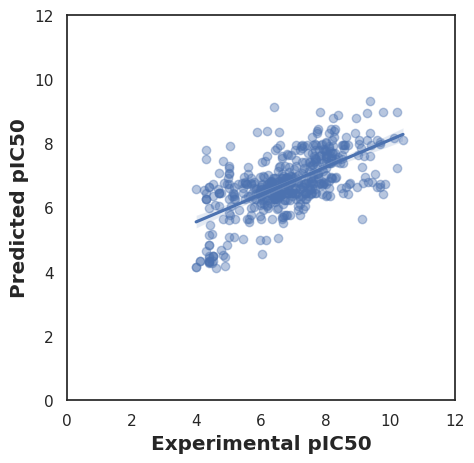

In [111]:
sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x = Y_test, y = Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show

In [127]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

In [128]:
# Performance table of the training set (80% subset)
train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
DecisionTreeRegressor,0.579268,0.582545,0.833906,0.017499
ExtraTreeRegressor,0.579268,0.582545,0.833906,0.017776
ExtraTreesRegressor,0.579268,0.582545,0.833906,0.408642
GaussianProcessRegressor,0.579268,0.582545,0.833906,17.294474
RandomForestRegressor,0.566016,0.569396,0.846938,0.318507
BaggingRegressor,0.559893,0.563321,0.852891,0.075992
HistGradientBoostingRegressor,0.507931,0.511764,0.901836,0.358660
SVR,0.466306,0.470463,0.939206,0.355089
MLPRegressor,0.466186,0.470344,0.939311,1.422355


In [129]:
test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
NuSVR,0.400980,0.419660,1.032079,0.190969
SVR,0.397865,0.416643,1.034758,0.217230
MLPRegressor,0.384246,0.403448,1.046395,1.277587
GradientBoostingRegressor,0.381936,0.401210,1.048356,0.169440
HistGradientBoostingRegressor,0.379910,0.399248,1.050073,-0.703829
RandomForestRegressor,0.364127,0.383957,1.063352,0.285721
BaggingRegressor,0.358339,0.378350,1.068181,0.049614
KNeighborsRegressor,0.313845,0.335242,1.104596,0.037442
ExtraTreesRegressor,0.278999,0.301484,1.132296,0.333821


[(0.0, 1.0)]

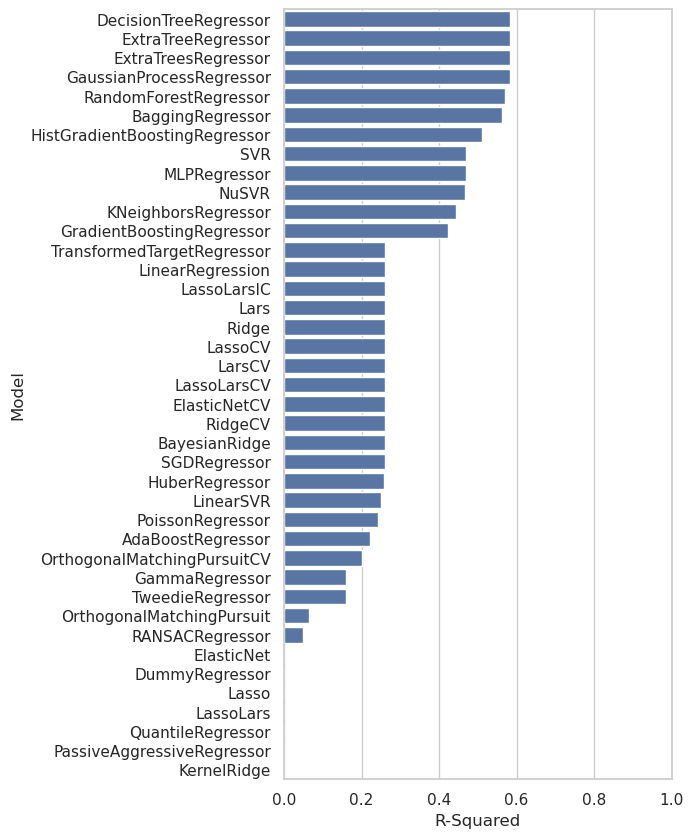

In [130]:
plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="R-Squared", data=train)
ax.set(xlim=(0, 1))

[(0.0, 1.0)]

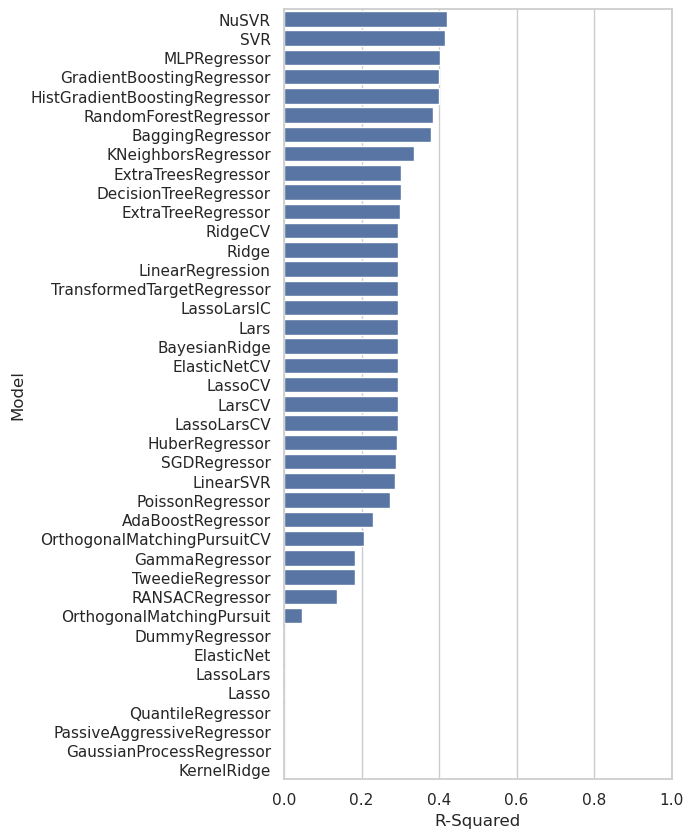

In [132]:
plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=test.index, x="R-Squared", data=test)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

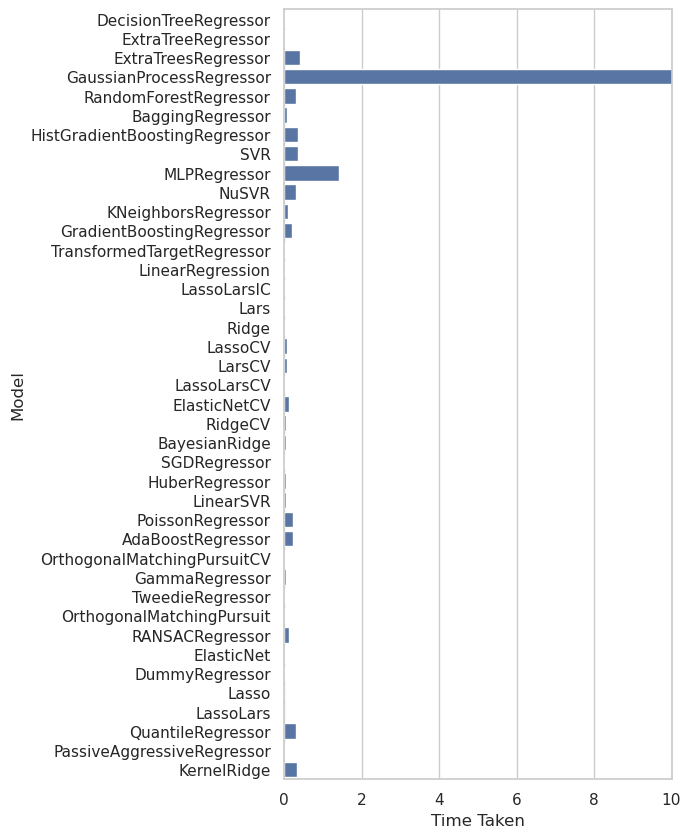

In [133]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="Time Taken", data=train)
ax.set(xlim=(0, 10))